# 94 — Match nodal individual events to Geode stack records

Uses:

- `geode_events` from notebook 92
- `nodal_source_estimates` from notebook 93

to find candidate individual nodal events belonging to each Geode stacked shot file.

Assumptions:

- Geode file time is final trigger in stack.
- `geode_events.stack_start_utc` and `stack_end_utc` define the candidate stack window.
- Match requires time-window overlap and source-position agreement.

## 1. Configuration

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Volumes/tachyon/LBSSP_DATA")
CATALOG_DB = PROJECT_ROOT / "catalog" / "lbssp_shot_catalog.sqlite"
OUT_ROOT = PROJECT_ROOT / "nodal_geode_match_exports"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SOURCE_TOLERANCE_M = 3.0
TIME_MARGIN_BEFORE_S = 0.0
TIME_MARGIN_AFTER_S = 0.0

# Optional: set to one survey for focused testing, e.g. "T1_1m_refraction"
TARGET_SURVEY = None

print("CATALOG_DB:", CATALOG_DB)
print("OUT_ROOT:", OUT_ROOT)

CATALOG_DB: /Volumes/tachyon/LBSSP_DATA/catalog/lbssp_shot_catalog.sqlite
OUT_ROOT: /Volumes/tachyon/LBSSP_DATA/nodal_geode_match_exports


## 2. Load tables

In [2]:
conn = sqlite3.connect(CATALOG_DB)

geode_events = pd.read_sql("SELECT * FROM geode_events", conn)
nodal_est = pd.read_sql("SELECT * FROM nodal_source_estimates", conn)

geode_events["stack_start_dt"] = pd.to_datetime(geode_events["stack_start_utc"], errors="coerce", utc=True)
geode_events["stack_end_dt"] = pd.to_datetime(geode_events["stack_end_utc"], errors="coerce", utc=True)
geode_events["final_dt"] = pd.to_datetime(geode_events["geode_final_trigger_time_utc"], errors="coerce", utc=True)
geode_events["source_x_m"] = pd.to_numeric(geode_events["source_x_m"], errors="coerce")

nodal_est["event_time_dt"] = pd.to_datetime(nodal_est["event_time_utc"], errors="coerce", utc=True)
nodal_est["estimated_source_x_m"] = pd.to_numeric(nodal_est["estimated_source_x_m"], errors="coerce")

if TARGET_SURVEY is not None:
    geode_events = geode_events[geode_events["survey"].astype(str).eq(TARGET_SURVEY)].copy()

print("geode_events:", len(geode_events))
print("nodal_est:", len(nodal_est))
display(geode_events.groupby("survey").size().reset_index(name="n"))
display(nodal_est.groupby("timewindow_label").size().reset_index(name="n"))

geode_events: 327
nodal_est: 3436


,survey,n
0,T1A_streamer_masw,87
1,T1_1m_refraction,46
2,T1_2m_refraction,42
3,T1_streamer_masw,83
4,T3_1m_refraction,39
5,T4_1m_refraction,30


,timewindow_label,n
0,T1_N1_Streamer,532
1,T1_N2_Nodal1,1376
2,T1_N2_Nodal2,81
3,T1_N2_Refraction1m,431
4,T1_N2_Refraction2m,450
5,T1_N3_Nodal3,43
6,T3_N4_Refraction1am,523


## 3. Build candidate associations

In [3]:
rows = []

for _, g in geode_events.iterrows():
    if pd.isna(g["stack_start_dt"]) or pd.isna(g["stack_end_dt"]) or not np.isfinite(g["source_x_m"]):
        continue

    start = g["stack_start_dt"] - pd.to_timedelta(TIME_MARGIN_BEFORE_S, unit="s")
    end = g["stack_end_dt"] + pd.to_timedelta(TIME_MARGIN_AFTER_S, unit="s")

    cand = nodal_est.copy()

    # Prefer expected nodal window if defined.
    tw = g.get("nodal_timewindow_label")
    if isinstance(tw, str) and tw and tw.lower() != "none":
        cand_tw = cand[cand["timewindow_label"].astype(str).eq(tw)].copy()
        if len(cand_tw):
            cand = cand_tw

    # Require same line where possible.
    if "line" in cand.columns and isinstance(g.get("line"), str):
        same_line = cand[cand["line"].astype(str).eq(str(g["line"]))].copy()
        if len(same_line):
            cand = same_line

    cand = cand[
        (cand["event_time_dt"] >= start) &
        (cand["event_time_dt"] <= end)
    ].copy()

    cand["source_x_residual_m"] = cand["estimated_source_x_m"] - float(g["source_x_m"])
    cand["abs_source_x_residual_m"] = cand["source_x_residual_m"].abs()

    cand = cand[cand["abs_source_x_residual_m"] <= SOURCE_TOLERANCE_M].copy()

    for _, n in cand.iterrows():
        dt_final_s = (n["event_time_dt"] - g["final_dt"]).total_seconds() if pd.notna(g["final_dt"]) else np.nan
        rows.append({
            "geode_event_id": g["geode_event_id"],
            "survey": g["survey"],
            "line": g["line"],
            "file_no": g["file_no"],
            "geode_source_x_m": g["source_x_m"],
            "source_type": g.get("source_type"),
            "n_stack_shots": g.get("n_stack_shots"),
            "geode_final_trigger_time_utc": g.get("geode_final_trigger_time_utc"),
            "stack_start_utc": g.get("stack_start_utc"),
            "stack_end_utc": g.get("stack_end_utc"),
            "nodal_event_id": n["event_id"],
            "nodal_timewindow_label": n["timewindow_label"],
            "nodal_event_time_utc": n["event_time_utc"],
            "estimated_source_x_m": n["estimated_source_x_m"],
            "source_x_residual_m": n["source_x_residual_m"],
            "abs_source_x_residual_m": n["abs_source_x_residual_m"],
            "time_from_final_trigger_s": dt_final_s,
            "source_x_method": n.get("source_x_method"),
            "component": n.get("component"),
            "mseed_path": n.get("mseed_path"),
        })

candidates = pd.DataFrame(rows)
print("candidates:", len(candidates))
display(candidates.head())

candidates: 410


,geode_event_id,survey,line,file_no,geode_source_x_m,source_type,n_stack_shots,geode_final_trigger_time_utc,stack_start_utc,stack_end_utc,nodal_event_id,nodal_timewindow_label,nodal_event_time_utc,estimated_source_x_m,source_x_residual_m,abs_source_x_residual_m,time_from_final_trigger_s,source_x_method,component,mseed_path
0,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,hammer,9,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,T1_N2_Refraction1m_T1_N2_E00003,T1_N2_Refraction1m,2026-05-18T16:07:44.010000+00:00,83.821893,-0.678107,0.678107,-46.490,weighted_top3_energy_hp25,Z,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
1,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,hammer,9,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,T1_N2_Refraction1m_T1_N2_E00004,T1_N2_Refraction1m,2026-05-18T16:07:53.424000+00:00,83.970530,-0.529470,0.529470,-37.076,weighted_top3_energy_hp25,Z,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
2,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,hammer,9,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,T1_N2_Refraction1m_T1_N2_E00005,T1_N2_Refraction1m,2026-05-18T16:08:00.014000+00:00,83.864182,-0.635818,0.635818,-30.486,weighted_top3_energy_hp25,Z,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
3,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,hammer,9,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,T1_N2_Refraction1m_T1_N2_E00006,T1_N2_Refraction1m,2026-05-18T16:08:06.598000+00:00,84.035583,-0.464417,0.464417,-23.902,weighted_top3_energy_hp25,Z,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
4,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,hammer,9,2026-05-18T16:08:30.500000+00:00,2026-05-18T16:07:42.500000+00:00,2026-05-18T16:08:32.500000+00:00,T1_N2_Refraction1m_T1_N2_E00007,T1_N2_Refraction1m,2026-05-18T16:08:13.404000+00:00,84.031521,-0.468479,0.468479,-17.096,weighted_top3_energy_hp25,Z,/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...


## 4. Summarize matches by Geode stack

In [4]:
if len(candidates):
    stack_summary = (
        candidates
        .groupby(["geode_event_id", "survey", "line", "file_no", "geode_source_x_m"], dropna=False)
        .agg(
            n_candidate_events=("nodal_event_id", "count"),
            first_nodal_time=("nodal_event_time_utc", "min"),
            last_nodal_time=("nodal_event_time_utc", "max"),
            median_abs_source_resid_m=("abs_source_x_residual_m", "median"),
            min_time_from_final_s=("time_from_final_trigger_s", "min"),
            max_time_from_final_s=("time_from_final_trigger_s", "max"),
        )
        .reset_index()
        .sort_values(["survey", "file_no"])
    )
else:
    stack_summary = pd.DataFrame()

display(stack_summary.head(50))

,geode_event_id,survey,line,file_no,geode_source_x_m,n_candidate_events,first_nodal_time,last_nodal_time,median_abs_source_resid_m,min_time_from_final_s,max_time_from_final_s
0,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,3006,84.5,6,2026-05-18T16:07:44.010000+00:00,2026-05-18T16:08:30.714000+00:00,0.520314,-46.490,0.214
1,GEODE_T1_1M_REFRACTION_F3008,T1_1m_refraction,T1,3008,88.5,3,2026-05-18T16:18:11.590000+00:00,2026-05-18T16:18:25.676000+00:00,0.158460,-20.910,-6.824
2,GEODE_T1_1M_REFRACTION_F3009,T1_1m_refraction,T1,3009,90.5,7,2026-05-18T16:20:09.242000+00:00,2026-05-18T16:20:52.060000+00:00,1.512838,-42.258,0.560
3,GEODE_T1_1M_REFRACTION_F3010,T1_1m_refraction,T1,3010,92.5,2,2026-05-18T16:25:40.704000+00:00,2026-05-18T16:25:50.720000+00:00,0.369446,-42.796,-32.780
4,GEODE_T1_1M_REFRACTION_F3011,T1_1m_refraction,T1,3011,94.5,6,2026-05-18T16:35:47.448000+00:00,2026-05-18T16:36:33.668000+00:00,0.076996,-46.052,0.168
5,GEODE_T1_1M_REFRACTION_F3012,T1_1m_refraction,T1,3012,96.5,5,2026-05-18T16:40:39.496000+00:00,2026-05-18T16:41:20.826000+00:00,0.566942,-41.004,0.326
6,GEODE_T1_1M_REFRACTION_F3013,T1_1m_refraction,T1,3013,98.5,4,2026-05-18T16:46:22.688000+00:00,2026-05-18T16:47:02.674000+00:00,0.140884,-39.812,0.174
7,GEODE_T1_1M_REFRACTION_F3014,T1_1m_refraction,T1,3014,100.5,5,2026-05-18T16:50:38.002000+00:00,2026-05-18T16:51:16.986000+00:00,0.781636,-38.498,0.486
8,GEODE_T1_1M_REFRACTION_F3016,T1_1m_refraction,T1,3016,102.5,6,2026-05-18T16:59:42.648000+00:00,2026-05-18T17:00:26.434000+00:00,1.720574,-43.852,-0.066
9,GEODE_T1_1M_REFRACTION_F3017,T1_1m_refraction,T1,3017,104.5,8,2026-05-18T17:02:56.308000+00:00,2026-05-18T17:03:43.538000+00:00,0.330298,-47.192,0.038


## 5. Write SQLite tables and CSV exports

In [5]:
candidates.to_sql("nodal_geode_stack_candidates", conn, if_exists="replace", index=False)
stack_summary.to_sql("nodal_geode_stack_summary", conn, if_exists="replace", index=False)
conn.commit()

candidates.to_csv(OUT_ROOT / "nodal_geode_stack_candidates.csv", index=False)
stack_summary.to_csv(OUT_ROOT / "nodal_geode_stack_summary.csv", index=False)

print("Wrote tables: nodal_geode_stack_candidates, nodal_geode_stack_summary")
print("CSV exports:", OUT_ROOT)

Wrote tables: nodal_geode_stack_candidates, nodal_geode_stack_summary
CSV exports: /Volumes/tachyon/LBSSP_DATA/nodal_geode_match_exports


## 6. QC plot: nodal estimates and Geode stack windows

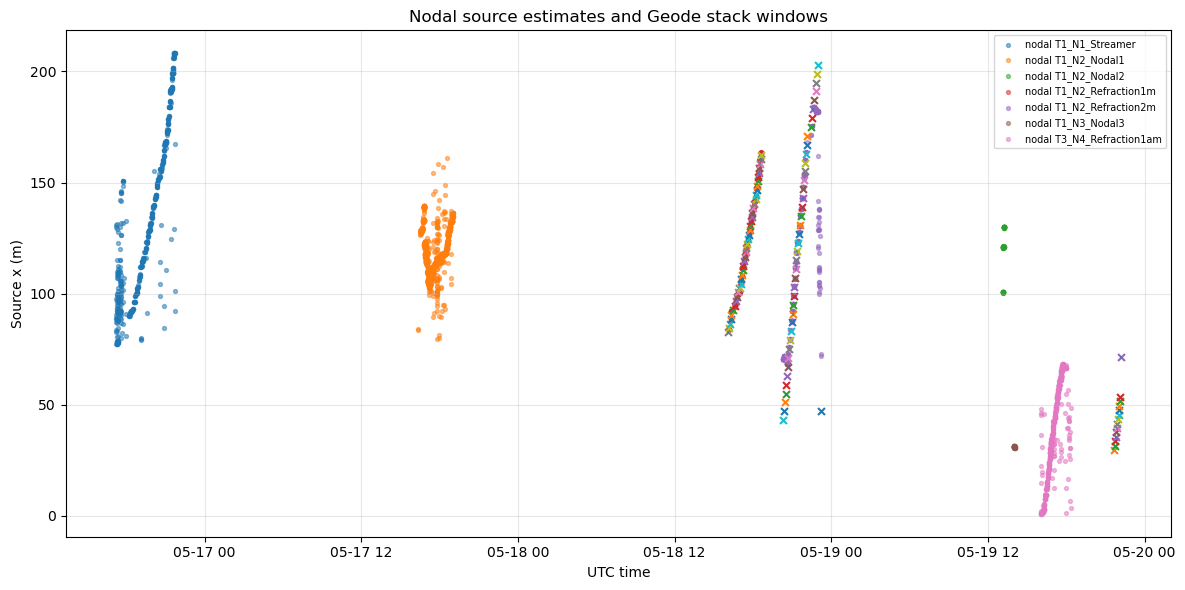

In [6]:
plot_n = nodal_est.copy()
plot_g = geode_events.copy()

fig, ax = plt.subplots(figsize=(12, 6))

for label, sub in plot_n.dropna(subset=["event_time_dt", "estimated_source_x_m"]).groupby("timewindow_label"):
    ax.scatter(sub["event_time_dt"], sub["estimated_source_x_m"], s=8, alpha=0.5, label=f"nodal {label}")

for _, g in plot_g.dropna(subset=["stack_start_dt", "stack_end_dt", "source_x_m"]).iterrows():
    ax.hlines(g["source_x_m"], g["stack_start_dt"], g["stack_end_dt"], linewidth=2)
    if pd.notna(g["final_dt"]):
        ax.scatter([g["final_dt"]], [g["source_x_m"]], s=25, marker="x")

ax.set_title("Nodal source estimates and Geode stack windows")
ax.set_xlabel("UTC time")
ax.set_ylabel("Source x (m)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()